**Machine Learning Project**


The numerical dataset 1. Student Performance.

In [8]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Importing the dataset
df= pd.read_csv('Student_Performance.csv')

In [10]:
# Explore the Data
# feature extraction phase
print(df.head())          # First few rows
print(df.columns)         # Column names
print(df.shape)           # Dimensions of the dataset
print(df.info())          # Column types & nulls
print(df.describe())      # Summary stats


   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  
Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')
(10000, 6)
<class 'p

Initial Visualization (Before Preprocessing)

In [11]:
# Initial Visualization (Before Preprocessing)
num_cols = ["Hours Studied", "Previous Scores", "Extracurricular Activities", " Sleep Hours",
"Sample Question Papers Practiced", "Performance Index"]


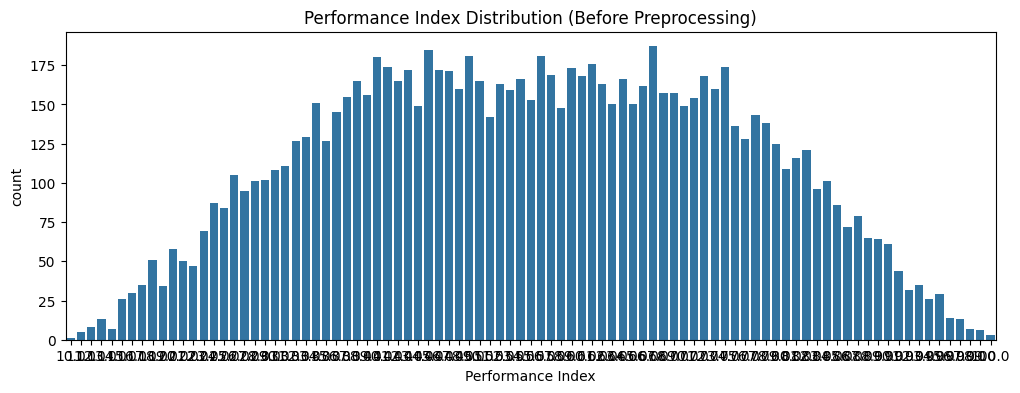

In [12]:
# Countplot
# Purpose: To visualize distribution of categorical variables.
# Check balance, Useful to spot imbalance issues that could bias the model.
plt.figure(figsize=(12,4))
sns.countplot(x="Performance Index", data=df)
plt.title("Performance Index Distribution (Before Preprocessing)")
plt.show()

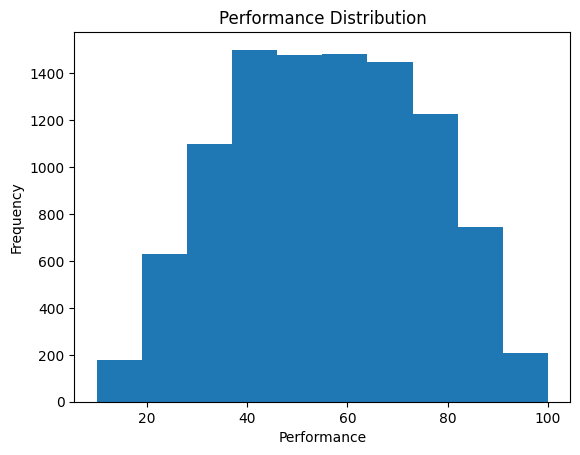

In [13]:
# Histograms (Before Preprocessing)
# Purpose: To see the distribution of a single variable.
# Check if data is normally distributed or skewed. Helps in deciding transformations (e.g., log-scaling).

plt.hist(df['Performance Index'], bins=10)  # bins = number of bars
plt.title("Performance Distribution")
plt.xlabel("Performance")
plt.ylabel("Frequency")
plt.show()


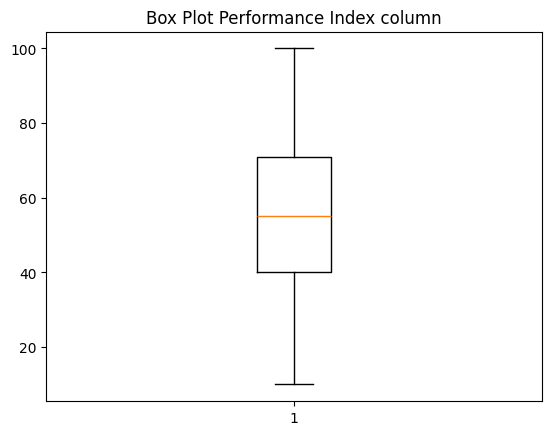

In [14]:
# Boxplots for each feature
# Purpose: To detect outliers and understand spread/variance.
# Use it on Income to quickly see if there are extreme values that might affect the model.

plt.boxplot(df['Performance Index'])
plt.title("Box Plot Performance Index column")
plt.show()

# Data pre-processing


In [16]:
# Data pre-processing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Fill missing values (in case there are missing values)
# Fill numeric columns with mean
# Fill categorical columns with mode
# Remove columns with any missing values

# Removing Duplicate Records
# Detect duplicate rows
duplicates = df[df.duplicated()]
# Remove duplicate rows (keep first occurrence)
df_no_duplicates = df.drop_duplicates()

# 1. Drop unnecessary columns as:Name , identifires (if exist) (in my data there is no exist of un necessary or miss leading columns )
# if 'Name' in df.columns:
#     df = df.drop(columns=['Name'])

# Filter out outliers
# Option 1: Outlier removal using IQR method
# Option 2: Z-score method for outlier detection

# Encode categorical columns
categorical_cols = ['Extracurricular Activities']
le = LabelEncoder()
# Corrected line: Apply LabelEncoder to the Series, not a DataFrame with one column
df[categorical_cols[0]] = le.fit_transform(df[categorical_cols[0]].astype(str))

# Separate features and target
X = df.drop(columns=['Performance Index'])
y = df['Performance Index']

# Handle imbalance with SMOTE
# in case there is

In [17]:
print(df.head())          # First few rows

   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 48)

In [19]:
#     FEATURE SCALING Method1 (MinMax Scaler)
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
X_train_scaled = mm.fit_transform(X_train)
X_test_scaled = mm.transform(X_test)

In [20]:
#     FEATURE SCALING Method2 (Standard Scaler)
std = StandardScaler()
X_train_scaled = std.fit_transform(X_train)
X_test_scaled = std.transform(X_test)

In [21]:
# dimension of resulted features.
print("features shape:", X.shape)

features shape: (10000, 5)


# Apply Linear regressors for Regression

In [23]:
# Define features and target
X = df.drop(columns=['Performance Index'])
y = df['Performance Index']

In [24]:
# Create and train the model
# Train-test split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
lr = LinearRegression()
# Fit (train) the model on the training data
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)



In [25]:
y_pred_lr = lr.predict(X_test_scaled)

# Show first 10 actual vs predicted
comparison = pd.DataFrame({
    'Actual ': y_test[:10],
    'Predicted ': y_pred_lr[:10]
})
print("First 10 Actual vs Predicted values:")
print(comparison)


First 10 Actual vs Predicted values:
      Actual   Predicted 
358      62.0   56.866136
8958     35.0   39.532233
1985     50.0   50.851839
1444     75.0   71.423391
1540     31.0   31.556745
6808     43.0   45.093706
9405     58.0   58.105809
749      69.0   69.610742
8668     79.0   82.712053
8253     70.0   66.985891


In [26]:
# 5-Fold Cross Validation
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5)

In [27]:
#Results details:
# For each model you should show all these results for your model on testing data (loss curve,
# accuracy, confusion matrix, ROC curve)
#     Linear Regression Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

lr_mse, lr_rmse, lr_mae, lr_r2 = metrics(y_test, y_pred_lr)

print("\n===== Linear Regression Results =====")
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2:", lr_r2)


===== Linear Regression Results =====
MSE: 4.179189661996083
RMSE: 2.0443066457838666
MAE: 1.6161668670263483
R2: 0.9886027439353303


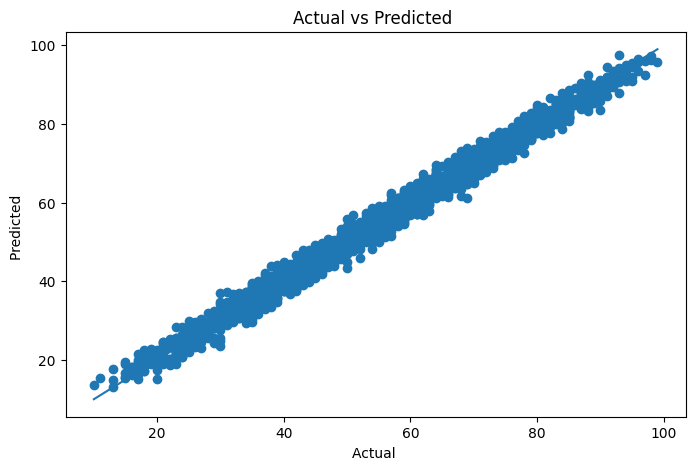

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual ")
plt.ylabel("Predicted ")
plt.title("Actual vs Predicted ")

# Line y = x for reference (perfect prediction)
# Find the smallest value across both actual and predicted MPG
min_val = min(y_test.min(), y_pred_lr.min())
# Find the largest value across both actual and predicted MPG
max_val = max(y_test.max(), y_pred_lr.max())
# Plot a straight line between (min_val, min_val) and (max_val, max_val)
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()


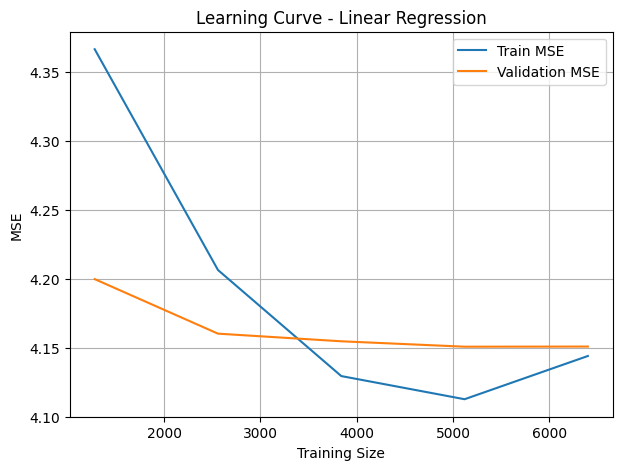

In [29]:
#          LEARNING CURVES
import seaborn as sns
from sklearn.model_selection import learning_curve # Import learning_curve

train_sizes = np.linspace(0.2, 1.0, 5)

def plot_learning_curve(model, title):
    train_sizes_lc, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train,
        cv=5, scoring="neg_mean_squared_error",
        train_sizes=train_sizes
    )

    train_mse = -train_scores.mean(axis=1)
    val_mse = -val_scores.mean(axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes_lc, train_mse, label="Train MSE")
    plt.plot(train_sizes_lc, val_mse, label="Validation MSE")
    plt.xlabel("Training Size")
    plt.ylabel("MSE")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

plot_learning_curve(lr, "Learning Curve - Linear Regression")

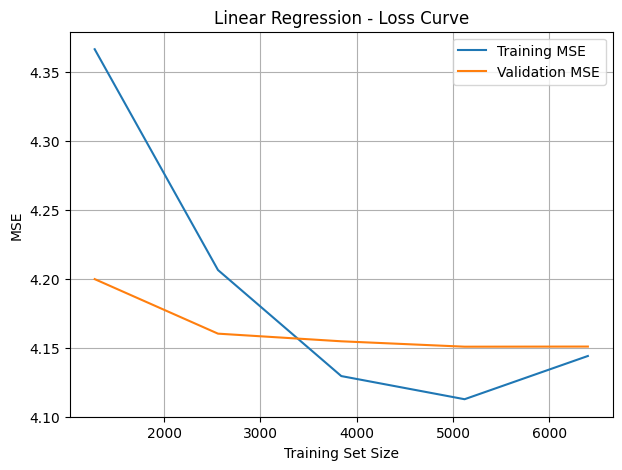

In [30]:
# Calculate Avg MSE
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]

train_sizes_lr, train_scores_lr, val_scores_lr = learning_curve(
    LinearRegression(),
    X_train_scaled, y_train,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=train_sizes
)

train_mse = -train_scores_lr.mean(axis=1)
val_mse = -val_scores_lr.mean(axis=1)

# Drow Loss Curve
plt.figure(figsize=(7,5))
plt.plot(train_sizes_lr, train_mse, label='Training MSE')
plt.plot(train_sizes_lr, val_mse, label='Validation MSE')
plt.xlabel('Training Set Size')
plt.ylabel('MSE')
plt.title('Linear Regression - Loss Curve')
plt.legend()
plt.grid()
plt.show()

# **Apply K-Nearest Neighbors (KNN) for regression**

In [31]:
# Step 1: Import necessary libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

In [32]:
# Step 3: Use Grid Search to find the best value for k (from 1 to 10)
param_grid = {'n_neighbors': range(1, 11)}  # Try k from 1 to 10
knn = KNeighborsRegressor()
grid_search = GridSearchCV(knn, param_grid, cv=5)  # 5-fold cross-validation
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': range(1, 11)})

In [33]:
# Step 4: Get the best value of k
best_k = grid_search.best_params_['n_neighbors']
print(f"Best value for k: {best_k}")

Best value for k: 10


In [34]:
# Step 6: Train KNN with the best k and make predictions
knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)

In [36]:
# Step 7: Calculate the accuracy
# The accuracy_score metric is not appropriate for regression tasks with continuous targets.
# This cell should be removed or replaced with regression metrics like MSE, RMSE, MAE, or R2.
# These metrics are already calculated for the KNN Regressor in cell X8_QpIqasegZ.

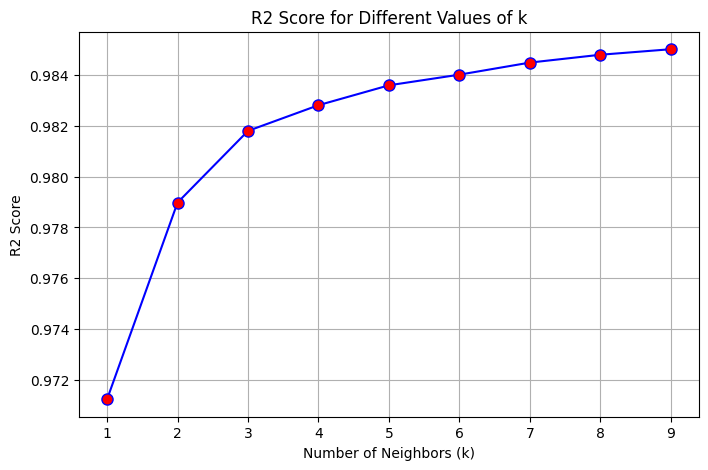

In [38]:
# Step 8: Visualize the R2 Score for different values of k
from sklearn.metrics import r2_score
k_values = range(1, 10)
r2_scores = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

# Plot the R2 scores for each value of k
plt.figure(figsize=(8, 5))
plt.plot(k_values, r2_scores, marker='o', linestyle='-', color='b', markerfacecolor='r', markersize=8)
plt.title('R2 Score for Different Values of k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('R2 Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [40]:
#       EVALUATION METRICS
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}
print("===== KNN Regressor Evaluation Metrics =====")
metrics_knn = regression_metrics(y_test, y_pred)
metrics_df = pd.DataFrame([metrics_knn], index=['KNN'])
print(metrics_df)



===== KNN Regressor Evaluation Metrics =====
          MSE      RMSE      MAE        R2
KNN  5.475755  2.340033  1.84335  0.985067


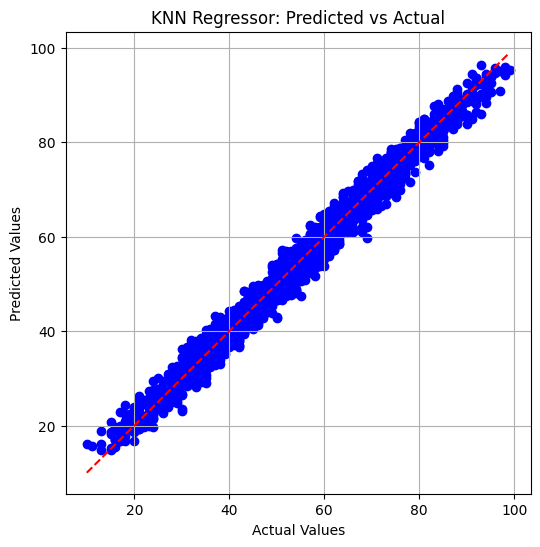

In [41]:
#       PREDICTED VS ACTUAL PLOT
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("KNN Regressor: Predicted vs Actual")
plt.grid()
plt.show()